# Reconocimiento Facial - Transfer Learning desde modelo CelebA

In [2]:
import tensorflow as tf
from tensorflow import keras
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import (
    Dense, Conv2D, MaxPooling2D, Flatten,
    Activation, Dropout,
    BatchNormalization
)
from keras.regularizers import l1_l2
from keras.models import Sequential, Model
import matplotlib.pyplot as plt
import numpy as np
import os

I0000 00:00:1790107470.412387   60437 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790107470.448121   60437 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790107471.549245   60437 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
            #Evita que TF reserve toda la VRAM al inicio
        print(f'GPU configurada: {len(gpus)} dispositivo(s)')
    except RuntimeError as e:
        print(e)
else:
    print('No se detectó GPU - usando CPU')

GPU configurada: 1 dispositivo(s)


In [4]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,             
    width_shift_range=0.1,      
    height_shift_range=0.1,     
    shear_range=0.1,                
    zoom_range=0.1,            
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2,
    brightness_range=[0.8, 1.2]
)

Preparamos los generadores de datos
He reunido 414 imágenes de mi rostro en diferentes escenarios, 

había empezado con menos pero hacia overfitting muy rápido.

Las 414 imágenes de desconocidos son de la base de datos CelabA

In [5]:
mis_clases_train = ['desconocidos', 'imagenes_mias']

data_gen_entrenamiento = datagen.flow_from_directory(
    'dataset/',
    target_size=(64, 64),
    batch_size=16,             
    shuffle=True,
    subset='training',
    color_mode='grayscale',
    class_mode='binary',
    classes=mis_clases_train
)

data_gen_validacion = datagen.flow_from_directory(
    'dataset/',
    target_size=(64, 64),
    batch_size=16,             
    shuffle=False,
    subset='validation',
    color_mode='grayscale',
    class_mode='binary',
    classes=mis_clases_train
)

print(f'Clases: {data_gen_entrenamiento.class_indices}')
print(f'Muestras entrenamiento: {data_gen_entrenamiento.samples}')
print(f'Muestras validación: {data_gen_validacion.samples}')

Found 663 images belonging to 2 classes.
Found 164 images belonging to 2 classes.
Clases: {'desconocidos': 0, 'imagenes_mias': 1}
Muestras entrenamiento: 663
Muestras validación: 164


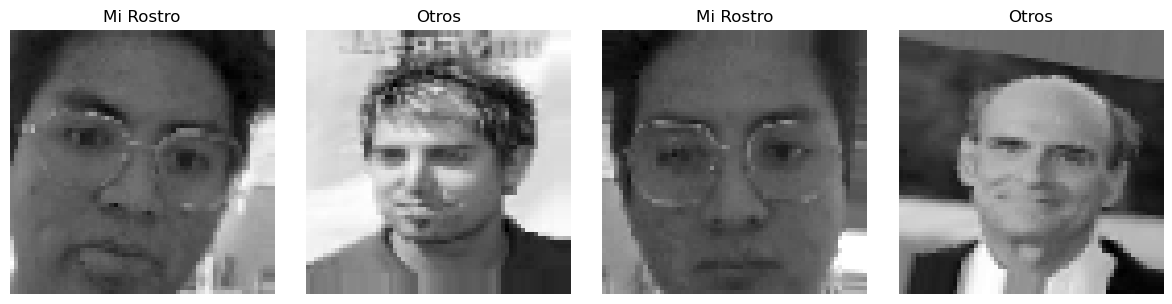

In [6]:
for inputs, targets in data_gen_entrenamiento:
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    for i, ax in enumerate(axes):
        ax.imshow(inputs[i].squeeze(), cmap='gray')
        label = 'Mi Rostro' if targets[i] > 0.5 else 'Otros'
        ax.set_title(label)
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    break

Cargando modelo preentrenado de CelebA

In [7]:
pretrained_model = tf.keras.models.load_model('best_model_celab_40.keras')
pretrained_model.summary()

I0000 00:00:1790107482.712263   60437 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6135 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,941,262 (7.41 MB)

 Trainable params: 647,012 (2.47 MB)

 Non-trainable params: 224 (896.00 B)

 Optimizer params: 1,294,026 (4.94 MB)

Cargamos el modelo y congelamos las capas del modelo base

In [ ]:
for layer in pretrained_model.layers:
    layer.trainable = False

conv_layers = [layer for layer in pretrained_model.layers if isinstance(layer, Conv2D)]
ultima_conv = conv_layers[-1]
ultima_conv.trainable = True 

pool_layers = [layer for layer in pretrained_model.layers if isinstance(layer, MaxPooling2D)]
feature_layer = pool_layers[-1].output 

#Si se quiere entrenar la densa y no la conv se añade este pedazo de código.
#densas = [layer for layer in pretrained_model.layers if isinstance(layer, Dense)]
#feature_layer = densas[-2].output 

base_model = Model(inputs=pretrained_model.input, outputs=feature_layer)
base_model.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,744 (92.75 KB)

 Trainable params: 18,496 (72.25 KB)

 Non-trainable params: 5,248 (20.50 KB)

In [ ]:
kernel_reg = l1_l2(1e-03, 1e-03)
model = Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dense(64, activation='relu', kernel_regularizer=kernel_reg))
model.add(Dropout(0.4))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_15 (Functional)      │ (None, 6, 6, 64)       │        23,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,329 (669.25 KB)

 Trainable params: 166,081 (648.75 KB)

 Non-trainable params: 5,248 (20.50 KB)

In [19]:
filepath = "best_model_ReconocimientoFacial.keras"
checkpoint = ModelCheckpoint(filepath, monitor='val_loss',
                    verbose=1, save_best_only=True, mode='min')
earlystop = EarlyStopping(monitor='val_loss',
                          mode='min',
                          restore_best_weights=True,
                          patience=10, verbose=1)
model.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=0.00001),
              metrics=['accuracy'])

In [20]:
history = model.fit(data_gen_entrenamiento,
                   epochs=400,
                   validation_data=data_gen_validacion,
                   callbacks=[checkpoint, earlystop],
                   verbose=1
                   )

Epoch 1/400


I0000 00:00:1790107892.668622   76528 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_50857__.45


10/42 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.3860 - loss: 4.9881

I0000 00:00:1790107894.341222   76527 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_50857__.45


40/42 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.4047 - loss: 4.9863
Epoch 1: val_loss improved from None to 4.66591, saving model to best_model_ReconocimientoFacial.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.4148 - loss: 4.9641 - val_accuracy: 0.5183 - val_loss: 4.6659
Epoch 2/400
40/42 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5484 - loss: 4.7079
Epoch 2: val_loss improved from 4.66591 to 4.54771, saving model to best_model_ReconocimientoFacial.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.5671 - loss: 4.6733 - val_accuracy: 0.5549 - val_loss: 4.5477
Epoch 3/400
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5509 - loss: 4.7064
Epoch 3: val_loss did not improve from 4.54771
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.5943 - loss: 4.6347 - val_accuracy: 0.5488 - val_loss: 4.5901
Epoch 4/400
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7088 - loss: 4.4352
Epoch 4: val_loss improved from 4.54771 to 4.46117, saving mode

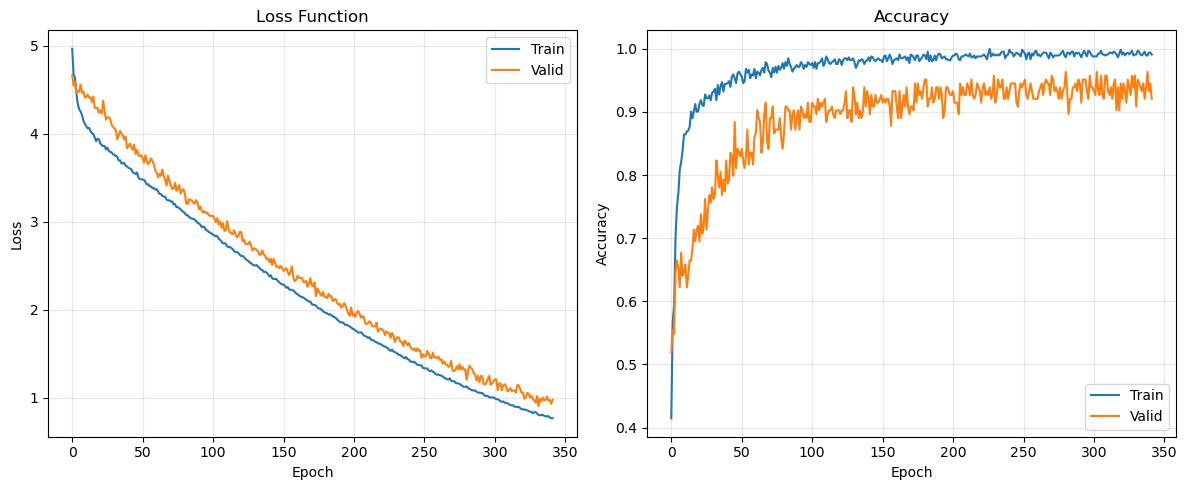

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(history.history['loss'], label='Train')
ax[0].plot(history.history['val_loss'], label='Valid')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Loss Function')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(history.history['accuracy'], label='Train')
ax[1].plot(history.history['val_accuracy'], label='Valid')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].set_title('Accuracy')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Pondremos a prueba el modelo con las imagenes test, imagenes que no vio en train ni validation

In [22]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
datagen_test = ImageDataGenerator(rescale=1./255)
mis_clases_test = ['desconocidos2', 'Jose_Ramon2']
test_gen = datagen_test.flow_from_directory(
    'dataset_test/',
    target_size=(64, 64),
    batch_size=4,
    shuffle=False, #False par poder graficar correctamente
    color_mode='grayscale',
    class_mode='binary',
    classes=mis_clases_test
)

print(f'Muestras test: {test_gen.samples}')
print(f'Clases: {test_gen.class_indices}')

Found 24 images belonging to 2 classes.
Muestras test: 24
Clases: {'desconocidos2': 0, 'Jose_Ramon2': 1}


In [24]:
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.8166
Test Loss: 0.8166
Test Accuracy: 1.0000


Podemos notar que predice correctamente el 100%

Veamos todas las imagenes de tes.

Cuales predijo bien y cuales mal, con el porcentaje marcado de ser desconocido o Jose 
Ramon

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


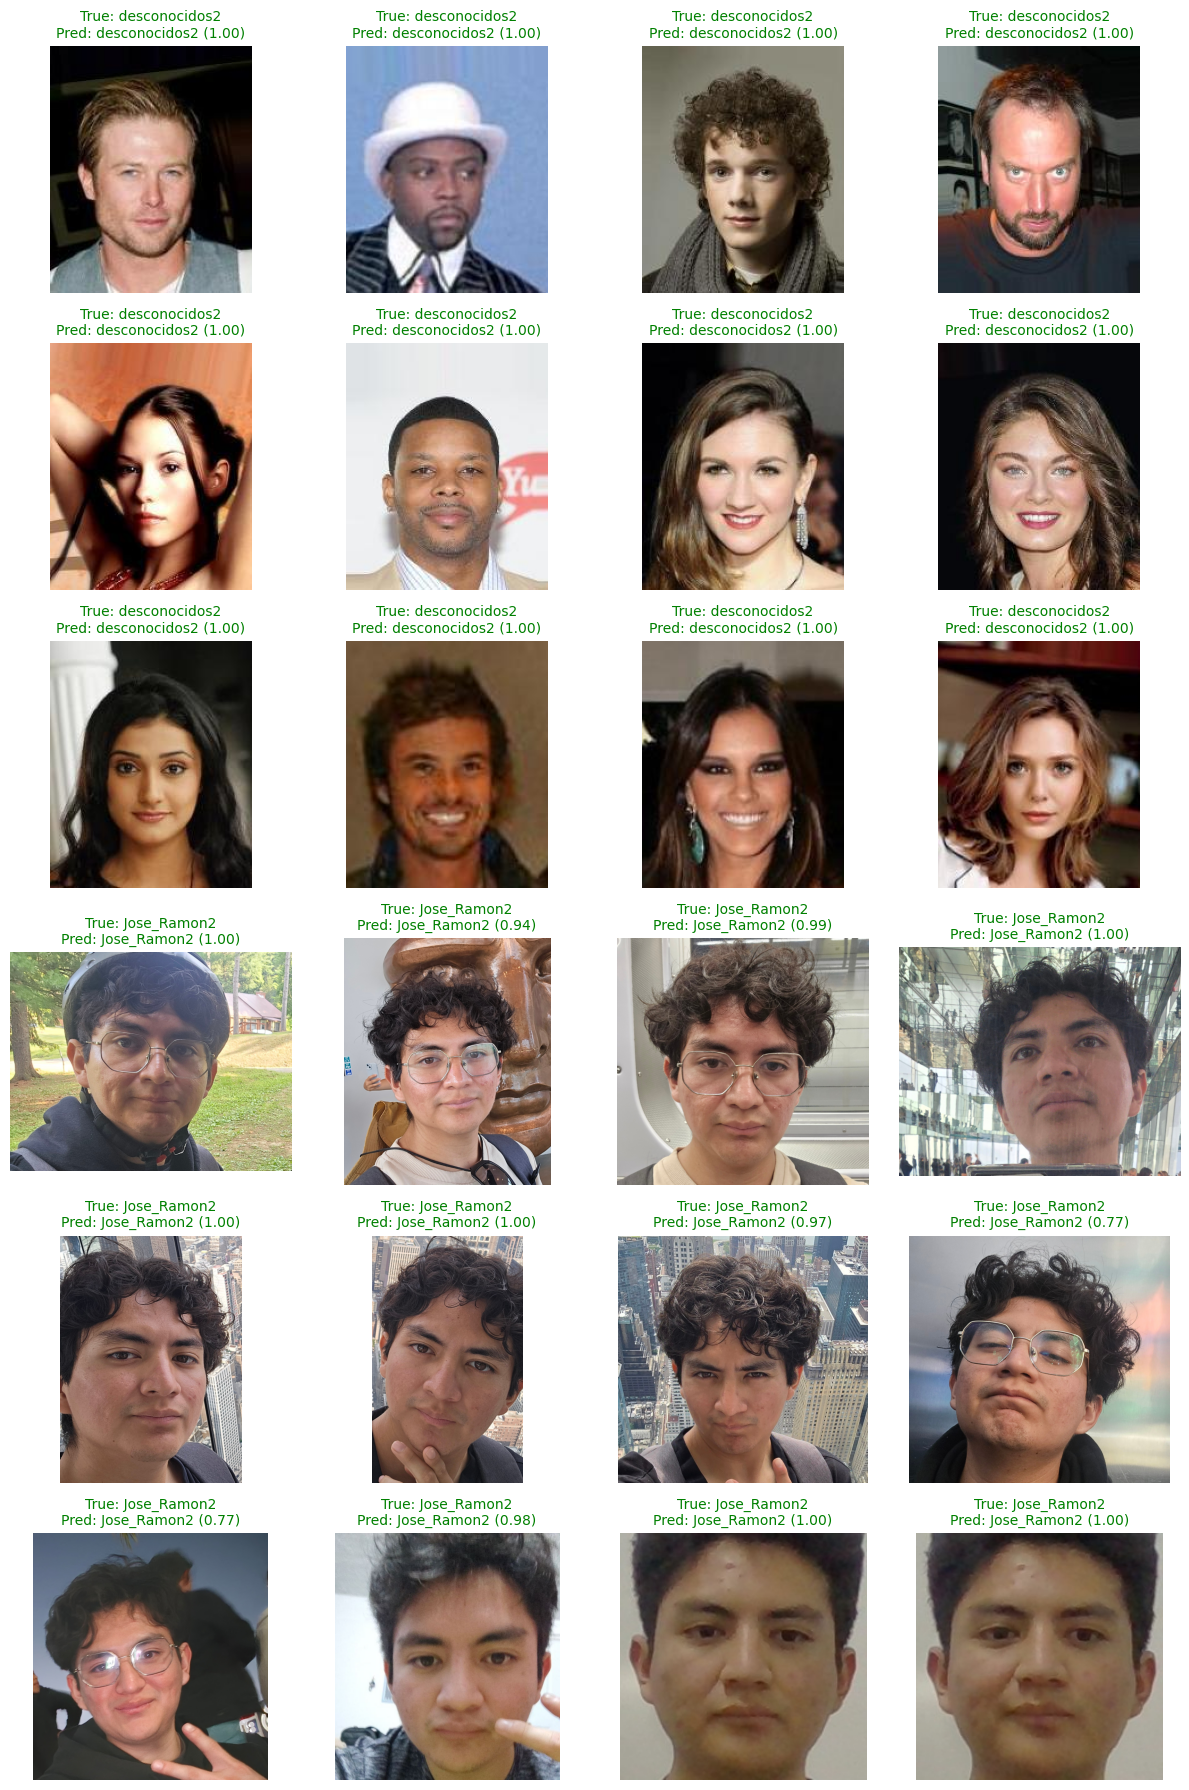

               precision    recall  f1-score   support

desconocidos2       1.00      1.00      1.00        12
  Jose_Ramon2       1.00      1.00      1.00        12

     accuracy                           1.00        24
    macro avg       1.00      1.00      1.00        24
 weighted avg       1.00      1.00      1.00        24



In [ ]:
predictions = model.predict(test_gen, verbose=1)
predicted_classes = (predictions > 0.5).astype(int).flatten()

true_classes = test_gen.classes
filenames = test_gen.filenames

#clase_valor = 0 o 1, clase_name = 'desconocidos2' o 'Jose_Ramon2'
class_labels = {clase_valor: clase_name for clase_name, clase_valor in test_gen.class_indices.items()}

# Mostramos todas las predicciones
n_samples = len(predictions)
cols = min(4, n_samples)
rows = (n_samples + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))

for idx in range(n_samples):
    r, c = divmod(idx, cols)
    ax = axes[r, c]

    img_path = os.path.join(test_gen.directory, filenames[idx])
    img = plt.imread(img_path)
    
    ax.imshow(img)
    
    true_label = class_labels[true_classes[idx]]
    pred_label = class_labels[predicted_classes[idx]]
    
    seguridad = predictions[idx][0] if predicted_classes[idx] == 1 else 1 - predictions[idx][0]
    
    color = 'green' if true_classes[idx] == predicted_classes[idx] else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({seguridad:.2f})', color=color, fontsize=10)
    ax.axis('off')

for idx in range(n_samples, rows * cols):
    r, c = divmod(idx, cols)
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()

print(classification_report(true_classes, predicted_classes, target_names=list(class_labels.values())))

### Para lograr este resultado tuvimos que entrenar una capa convolucional y unas densas, si no se añade el entrenamiento de la capa convolucional los resultaos no llegan a ser buenos.

## Ahora veamos la comparación con una red pre-entrenada, MobilNet2

In [77]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

Para el modelo MobilNet2 el menor target es de (96,96, 3)

In [127]:
mis_clases_train = ['desconocidos', 'imagenes_mias']
data_gen_entrenamiento_mobi = datagen.flow_from_directory(
    'dataset/',
    target_size=(96, 96),
    batch_size=16,             
    shuffle=True,
    subset='training',
    color_mode='rgb',
    class_mode='binary',
    classes=mis_clases_train
)

data_gen_validacion_mobi = datagen.flow_from_directory(
    'dataset/',
    target_size=(96, 96),
    batch_size=16,             
    shuffle=False,
    subset='validation',
    color_mode='rgb',
    class_mode='binary',
    classes=mis_clases_train
)

Found 663 images belonging to 2 classes.


Found 164 images belonging to 2 classes.


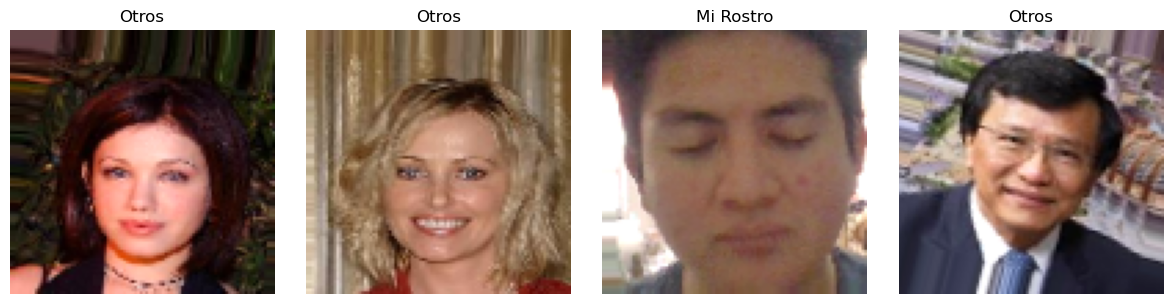

In [128]:
for inputs, targets in data_gen_entrenamiento_mobi:
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    for i, ax in enumerate(axes):
        ax.imshow(inputs[i])
        label = 'Mi Rostro' if targets[i] > 0.5 else 'Otros'
        ax.set_title(label)
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    break

In [ ]:
base_mobilnet = MobileNetV2(
    input_shape=(96, 96, 3), 
    include_top=False,       # Cortamos la cabeza original de 1000 clases
    weights='imagenet'       
)
base_mobilnet.trainable = False 

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [107]:
model_mobilnet = Sequential()
model_mobilnet.add(base_mobilnet)
model_mobilnet.add(GlobalAveragePooling2D())
model_mobilnet.add(Dropout(0.4))
model_mobilnet.add(Dense(32, activation='relu', kernel_regularizer=l2(1e-03)))
model_mobilnet.add(Dense(1, activation='sigmoid'))
model_mobilnet.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │        40,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,299,009 (8.77 MB)

 Trainable params: 41,025 (160.25 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [108]:
filepath = "best_model_ReconocimientoFacial_mobilnet.keras"
checkpoint = ModelCheckpoint(filepath, monitor='val_loss',
                    verbose=1, save_best_only=True, mode='min')
earlystop = EarlyStopping(monitor='val_loss',
                          mode='min',
                          restore_best_weights=True,
                          patience=10, verbose=1)
model_mobilnet.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=0.00001),
              metrics=['accuracy'])

In [109]:
history_mobi = model_mobilnet.fit(data_gen_entrenamiento_mobi,
                   epochs=400,
                   validation_data=data_gen_validacion_mobi,
                   callbacks=[checkpoint, earlystop],
                   verbose=1
                   )

Epoch 1/400


I0000 00:00:1790098375.893917   11518 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_325427__.117
E0000 00:00:1790098377.125575   11518 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


14/42 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.4764 - loss: 0.8189

I0000 00:00:1790098381.370495   11517 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_325427__.117
E0000 00:00:1790098383.535758   11517 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.5003 - loss: 0.8165

E0000 00:00:1790098391.458376   11518 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_loss improved from None to 0.72587, saving model to best_model_ReconocimientoFacial_mobilnet.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 21s 337ms/step - accuracy: 0.5430 - loss: 0.7937 - val_accuracy: 0.5915 - val_loss: 0.7259
Epoch 2/400
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6024 - loss: 0.7791
Epoch 2: val_loss improved from 0.72587 to 0.71444, saving model to best_model_ReconocimientoFacial_mobilnet.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.6018 - loss: 0.7527 - val_accuracy: 0.6402 - val_loss: 0.7144
Epoch 3/400
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5922 - loss: 0.7347
Epoch 3: val_loss improved from 0.71444 to 0.69139, saving model to best_model_ReconocimientoFacial_mobilnet.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.6078 - loss: 0.7228 - val_accuracy: 0.6646 - val_loss: 0.6914
Epoch 4/400
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6525 - loss: 0.6861
Epoch 4: val_loss improved from 0.69139 to 0.6770

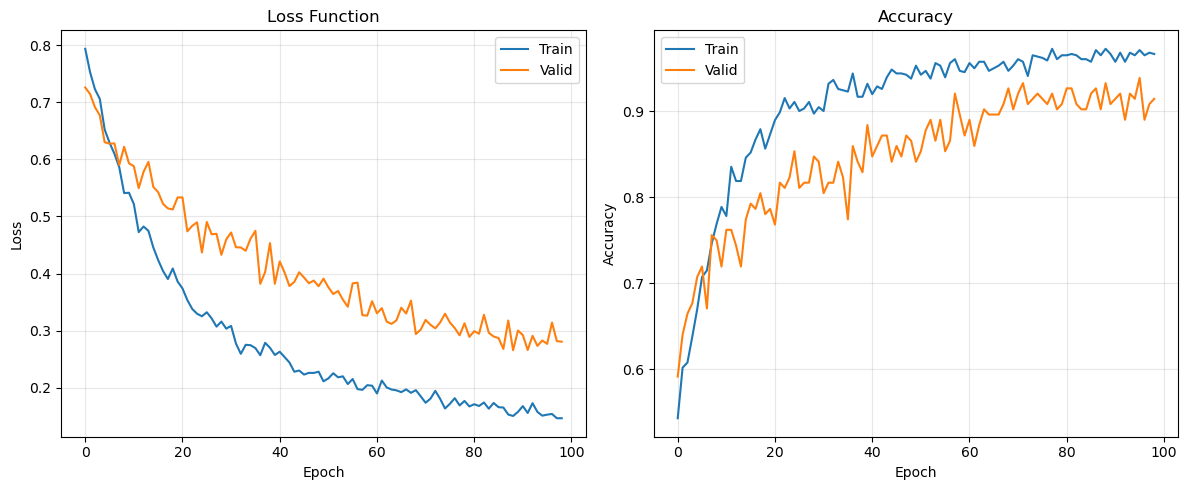

In [110]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(history_mobi.history['loss'], label='Train')
ax[0].plot(history_mobi.history['val_loss'], label='Valid')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Loss Function')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(history_mobi.history['accuracy'], label='Train')
ax[1].plot(history_mobi.history['val_accuracy'], label='Valid')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].set_title('Accuracy')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [138]:
datagen_test_mobi = ImageDataGenerator(rescale=1./255)
mis_clases_test = ['desconocidos2', 'Jose_Ramon2']
test_gen_mobi = datagen_test_mobi.flow_from_directory(
    'dataset_test/',
    target_size=(96, 96),
    batch_size=4,
    shuffle=False,
    color_mode='rgb',
    class_mode='binary',
    classes=mis_clases_test
)

print(f'Muestras test: {test_gen_mobi.samples}')
print(f'Clases: {test_gen_mobi.class_indices}')

Found 24 images belonging to 2 classes.
Muestras test: 24
Clases: {'desconocidos2': 0, 'Jose_Ramon2': 1}


In [ ]:
test_loss, test_acc = model_mobilnet.evaluate(test_gen_mobi, verbose=1)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9583 - loss: 0.1383
Test Loss: 0.1383
Test Accuracy: 0.9583


Podemos notar que predice bien el 95%

Veamos todas las imagenes de tes.

Cuales predijo bien y cuales mal, con el porcentaje marcado de ser desconocido o Jose 
Ramon

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


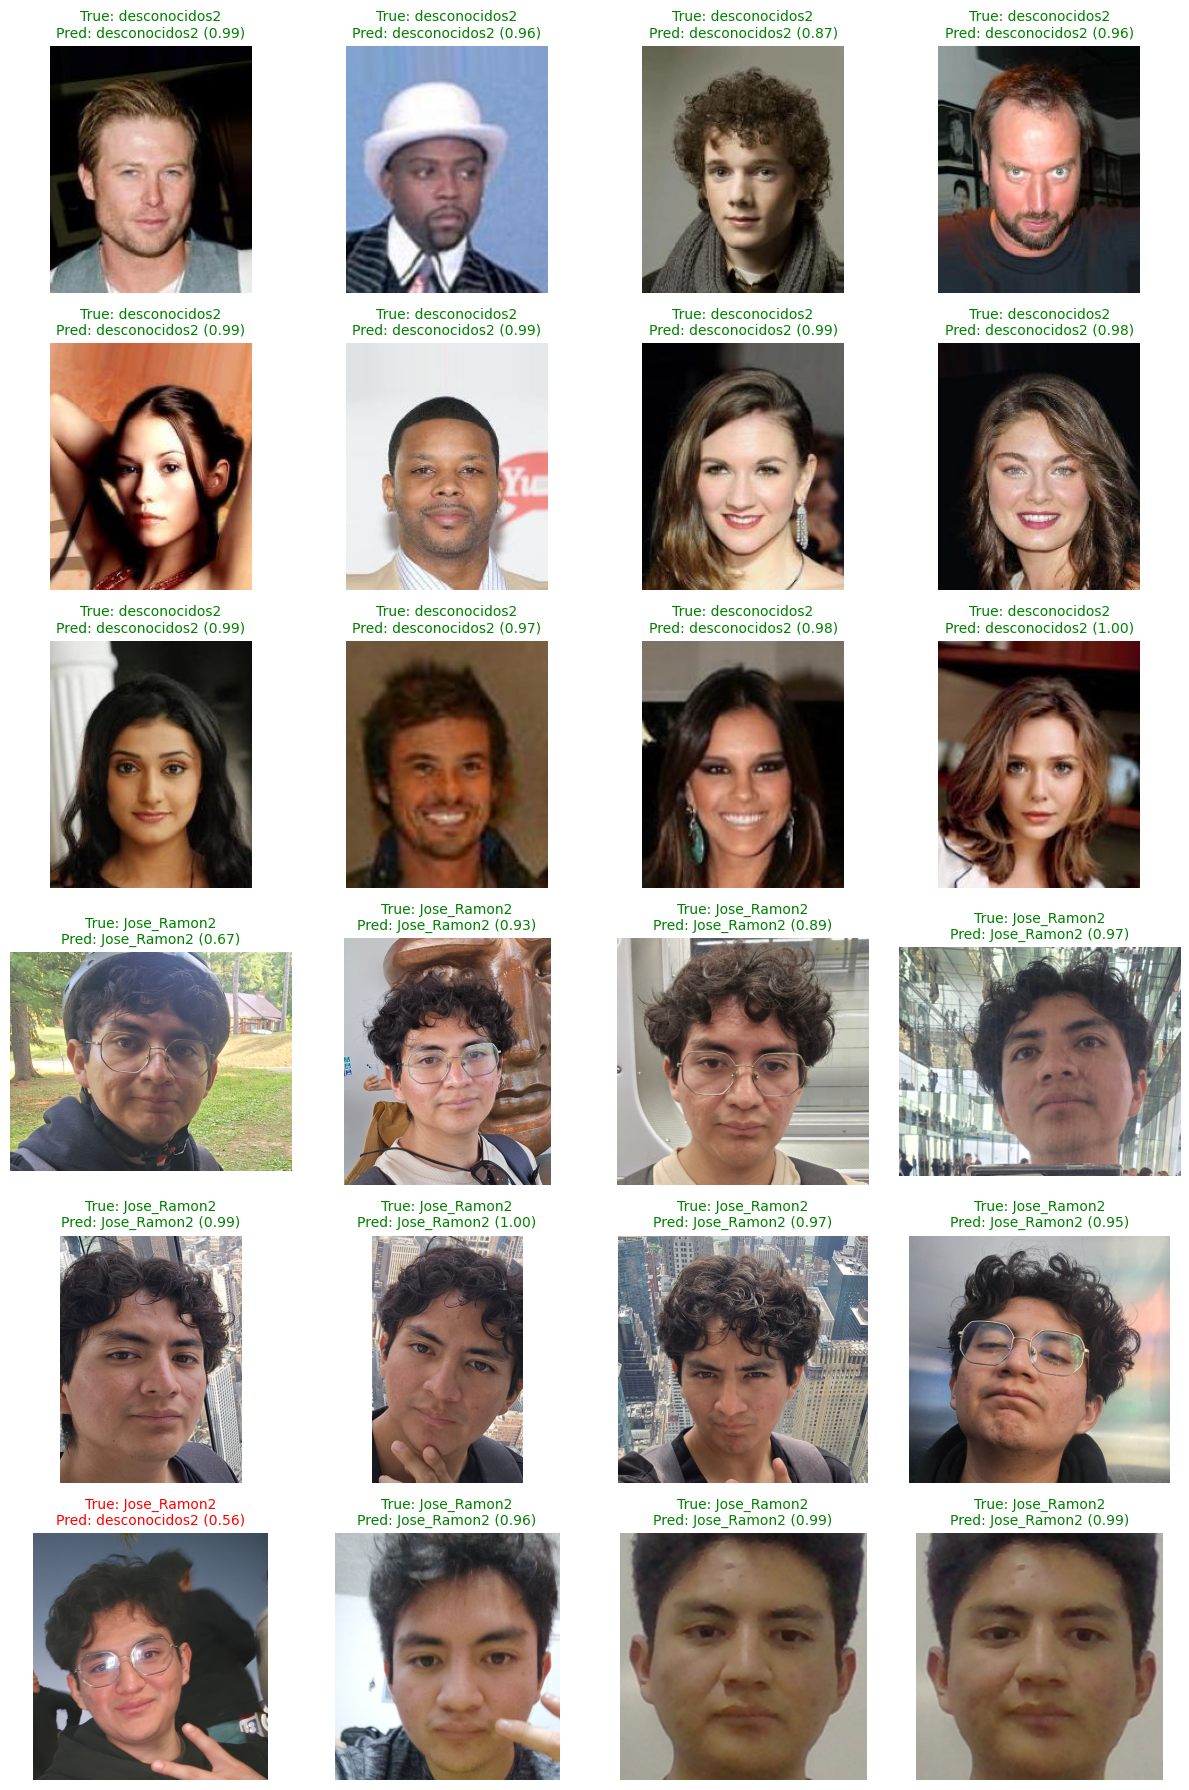

               precision    recall  f1-score   support

desconocidos2       0.92      1.00      0.96        12
  Jose_Ramon2       1.00      0.92      0.96        12

     accuracy                           0.96        24
    macro avg       0.96      0.96      0.96        24
 weighted avg       0.96      0.96      0.96        24



In [ ]:
predictions = model_mobilnet.predict(test_gen_mobi, verbose=1)
predicted_classes = (predictions > 0.5).astype(int).flatten()

true_classes = test_gen_mobi.classes
filenames = test_gen_mobi.filenames

#clase_valor = 0 o 1, clase_name = 'desconocidos2' o 'Jose_Ramon2'
class_labels = {clase_valor: clase_name for clase_name, clase_valor in test_gen_mobi.class_indices.items()}

# Mostramos todas las predicciones
n_samples = len(predictions)
cols = min(4, n_samples)
rows = (n_samples + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))

for idx in range(n_samples):
    r, c = divmod(idx, cols)
    ax = axes[r, c]

    img_path = os.path.join(test_gen_mobi.directory, filenames[idx])
    img = plt.imread(img_path)
    
    ax.imshow(img)
    
    true_label = class_labels[true_classes[idx]]
    pred_label = class_labels[predicted_classes[idx]]
    
    seguridad = predictions[idx][0] if predicted_classes[idx] == 1 else 1 - predictions[idx][0]
    
    color = 'green' if true_classes[idx] == predicted_classes[idx] else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({seguridad:.2f})', color=color, fontsize=10)
    ax.axis('off')

for idx in range(n_samples, rows * cols):
    r, c = divmod(idx, cols)
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()

print(classification_report(true_classes, predicted_classes, target_names=list(class_labels.values())))

### Notese que el resultado de esta red es similar a la entrenada con CelabA, pero la diferencia es que este modelo solo se entrenó una densa de 32 parámetros, por lo que los parámetros a entrenar fueron menos, además esta red fue entrenada para identificar objetos por lo que los pesos de sus capas convolucionales son más adecuados para esta tarea.